In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.io as pio


import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Seaborn style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
file_path = "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.shape

(7043, 21)

In [4]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [5]:
df.dtypes.to_frame(name="Data Type")

,Data Type
customerID,str
gender,str
SeniorCitizen,int64
Partner,str
Dependents,str
tenure,int64
PhoneService,str
MultipleLines,str
InternetService,str
OnlineSecurity,str


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df[df["TotalCharges"].str.strip() == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [10]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [11]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [12]:
df[df["TotalCharges"].isnull()][
    [
        "customerID",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Churn"
    ]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [13]:
df.loc[
    df["TotalCharges"].isnull() & (df["tenure"] == 0),
    "TotalCharges"
] = 0

In [14]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [15]:
for column in df.columns:
    print("\n", column)
    print(df[column].unique())


 customerID
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

 gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

 SeniorCitizen
[0 1]

 Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

 Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

 tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]

 PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

 MultipleLines
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

 InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Lengt

In [16]:
churn_distribution = pd.DataFrame({
    "Customers": df["Churn"].value_counts(),
    "Percentage": df["Churn"].value_counts(normalize=True) * 100
})

churn_distribution

,Customers,Percentage
Churn,,
No,5174,73.463013
Yes,1869,26.536987


In [17]:
churn_rate = (
    df["Churn"]
    .value_counts(normalize=True)["Yes"]
    * 100
)

print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 26.54%


In [72]:
import os

# Create Reports folder
reports_folder = "../Reports"

os.makedirs(reports_folder, exist_ok=True)

print(f"Reports folder ready: {reports_folder}")

Reports folder ready: ../Reports


In [73]:
reports_folder = "Reports"

os.makedirs(reports_folder, exist_ok=True)

# Overall Churn Rate is 26.54%

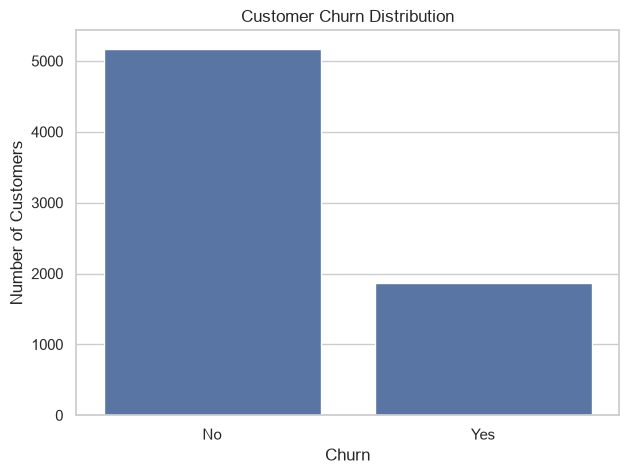

In [74]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.savefig(
    os.path.join(reports_folder, "01_customer_churn_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [66]:
fig = px.pie(
    df,
    names="Churn",
    title="Customer Churn Distribution",
    hole=0.4
)

fig.show()

plt.savefig("../Repots")

<Figure size 640x480 with 0 Axes>

In [20]:
numeric_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

In [21]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


# Are customers mostly new or long-term customers?

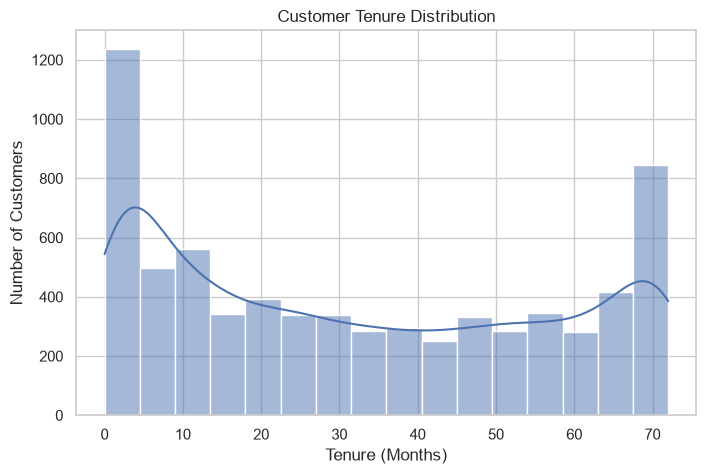

In [75]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="tenure",
    kde=True
)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.savefig(
    os.path.join(reports_folder, "02_tenure_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# Distribution of Monthly Charges

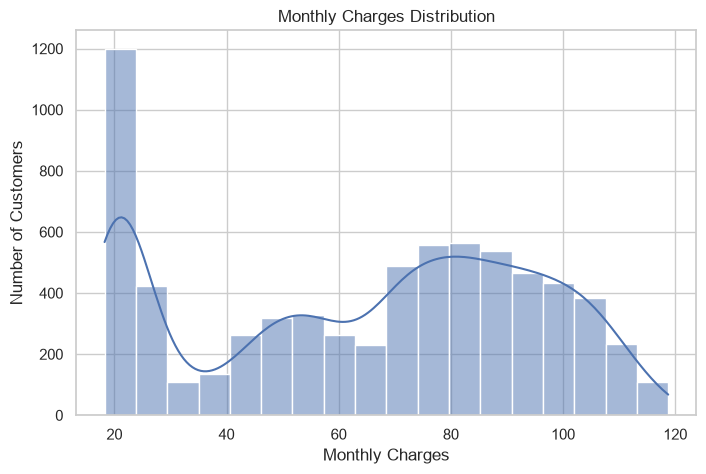

In [76]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    kde=True
)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.savefig(
    os.path.join(reports_folder, "03_monthly_charges_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Distribution of Total Charges

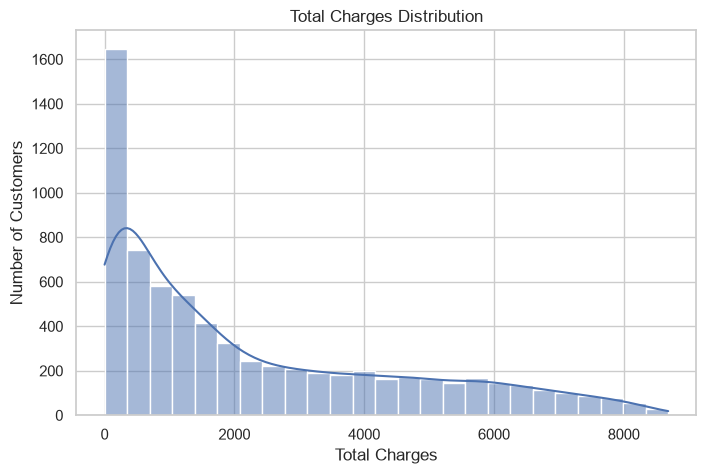

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="TotalCharges",
    kde=True
)

plt.title("Total Charges Distribution")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")


plt.show()

# Boxplots for Outlier Analysis
## Tenure

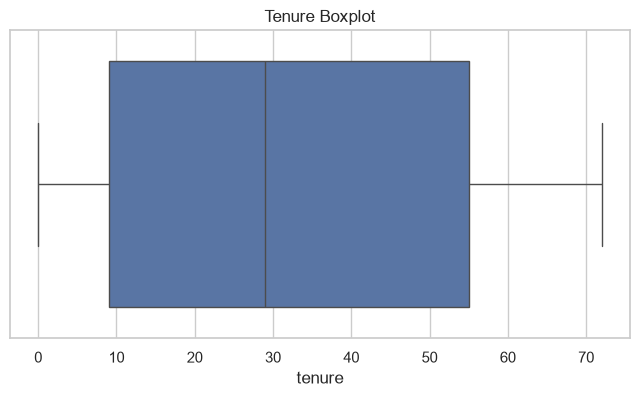

In [26]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df["tenure"]
)

plt.title("Tenure Boxplot")

plt.show()

# Monthly Changes

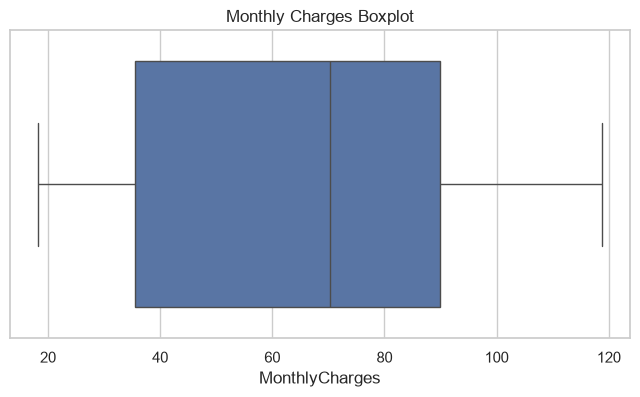

In [27]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df["MonthlyCharges"]
)

plt.title("Monthly Charges Boxplot")

plt.show()

# Total Charges

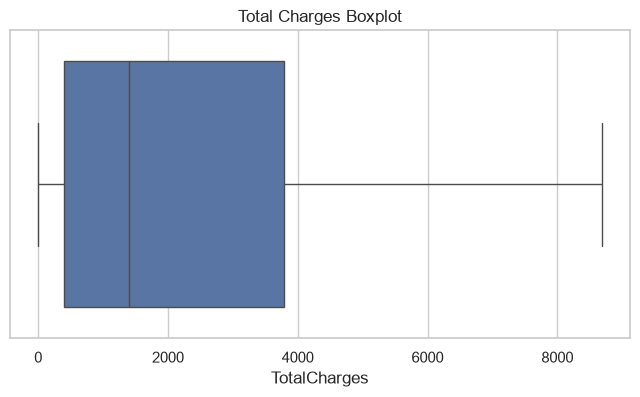

In [28]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df["TotalCharges"]
)

plt.title("Total Charges Boxplot")

plt.show()

# Churn vs Tenure

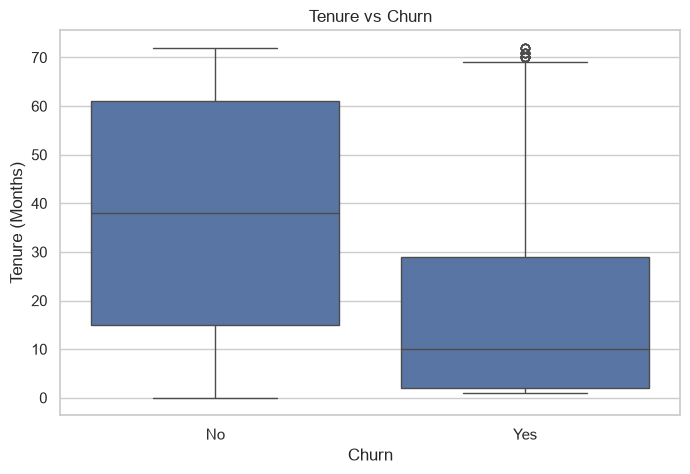

In [77]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.savefig(
    os.path.join(reports_folder, "04_tenure_vs_churn.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [30]:
df.groupby("Churn")["tenure"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Churn,,,,,
No,5174,37.569965,38.0,0,72
Yes,1869,17.979133,10.0,1,72


In [31]:
# Creating tenure groups
bins = [-1, 6, 12, 24, 48, np.inf]

labels = [
    "0-6 months",
    "7-12 months",
    "13-24 months",
    "25-48 months",
    "49+ months"
]

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=bins,
    labels=labels
)

In [32]:
df["TenureGroup"].value_counts().sort_index()

TenureGroup
0-6 months      1481
7-12 months      705
13-24 months    1024
25-48 months    1594
49+ months      2239
Name: count, dtype: int64

# Churn Rate by Tenure Group

In [33]:
tenure_churn = (
    df.groupby(
        "TenureGroup",
        observed=False
    )["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

tenure_churn

TenureGroup
0-6 months      52.937205
7-12 months     35.886525
13-24 months    28.710938
25-48 months    20.388959
49+ months       9.513176
Name: Churn, dtype: float64

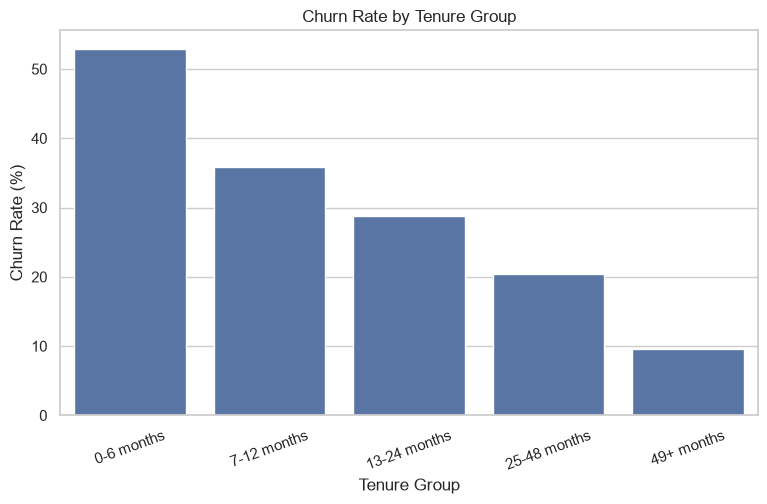

In [34]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=tenure_churn.index,
    y=tenure_churn.values
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)

plt.show()

# Contract vs Churn

In [35]:
contract_churn = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

contract_churn

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

In [78]:
fig = px.bar(
    contract_churn.reset_index(),
    x="Contract",
    y="Churn",
    title="Churn Rate by Contract Type",
    labels={"Churn": "Churn Rate (%)"},
    text="Churn"
)

plt.savefig(
    os.path.join(reports_folder, "05_contract_vs_churn.png"),
    dpi=300,
    bbox_inches="tight"
)
fig.show()

<Figure size 640x480 with 0 Axes>

# Internet Service vs Churn

In [37]:
internet_churn = (
    df.groupby("InternetService")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

internet_churn

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Churn, dtype: float64

In [79]:
fig = px.bar(
    internet_churn.reset_index(),
    x="InternetService",
    y="Churn",
    title="Churn Rate by Internet Service",
    labels={"Churn": "Churn Rate (%)"},
    text="Churn"
)

plt.savefig(
    os.path.join(reports_folder, "06_internet_service_vs_churn.png"),
    dpi=300,
    bbox_inches="tight"
)
fig.show()

<Figure size 640x480 with 0 Axes>

# Payment Method vs Churn

In [39]:
payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

payment_churn

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn, dtype: float64

In [80]:
fig = px.bar(
    payment_churn.reset_index(),
    x="PaymentMethod",
    y="Churn",
    title="Churn Rate by Payment Method",
    labels={"Churn": "Churn Rate (%)"},
    text="Churn"
)

fig.update_xaxes(tickangle=-25)

plt.savefig(
    os.path.join(reports_folder, "07_payment_method_vs_churn.png"),
    dpi=300,
    bbox_inches="tight"
)
fig.show()

<Figure size 640x480 with 0 Axes>

# Monthly Charges vs Churn

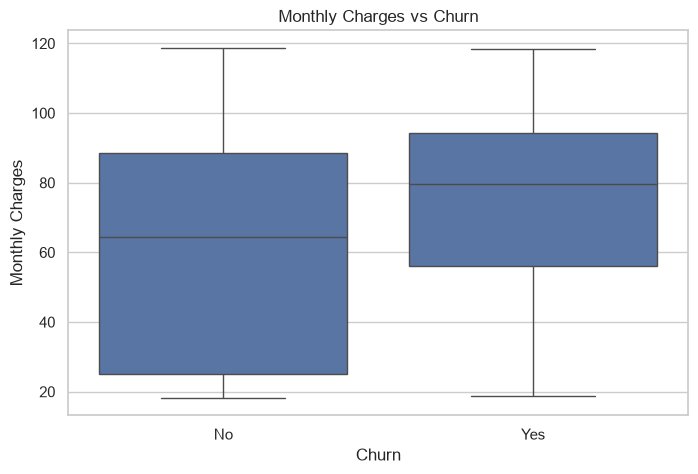

In [81]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.savefig(
    os.path.join(reports_folder, "08_monthly_charges_vs_churn.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [42]:
df.groupby("Churn")["MonthlyCharges"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
Churn,,,,
No,61.265124,64.425,18.25,118.75
Yes,74.441332,79.650,18.85,118.35


# Total charges vs Churn

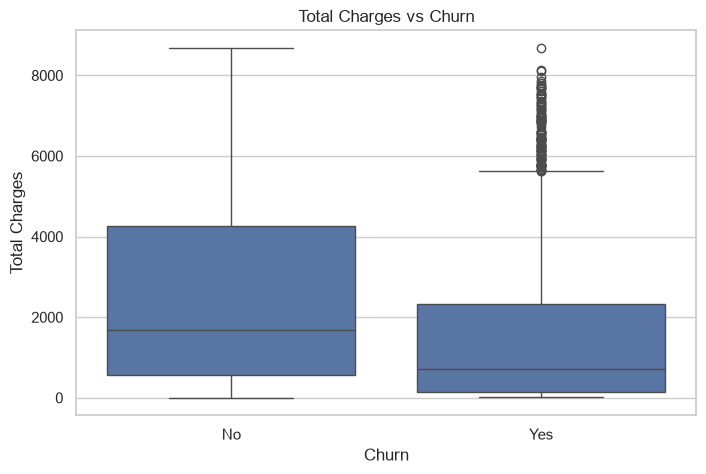

In [82]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.savefig(
    os.path.join(reports_folder, "09_customer_services_vs_churn.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [44]:
# Analyse customer service

service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

## Does having Tech Support relate to lower churn?

In [45]:
for column in service_columns:

    churn_rate = (
        df.groupby(column)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )

    print("\n", column)
    print(churn_rate)


 OnlineSecurity
OnlineSecurity
No                     41.766724
Yes                    14.611194
No internet service     7.404980
Name: Churn, dtype: float64

 OnlineBackup
OnlineBackup
No                     39.928756
Yes                    21.531494
No internet service     7.404980
Name: Churn, dtype: float64

 DeviceProtection
DeviceProtection
No                     39.127625
Yes                    22.502064
No internet service     7.404980
Name: Churn, dtype: float64

 TechSupport
TechSupport
No                     41.635474
Yes                    15.166341
No internet service     7.404980
Name: Churn, dtype: float64

 StreamingTV
StreamingTV
No                     33.523132
Yes                    30.070188
No internet service     7.404980
Name: Churn, dtype: float64

 StreamingMovies
StreamingMovies
No                     33.680431
Yes                    29.941435
No internet service     7.404980
Name: Churn, dtype: float64


In [46]:
# Customer Services Analysis

service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

service_churn_data = []

for service in service_columns:
    churn_rate = (
        df.groupby(service)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .reset_index()
    )
    
    churn_rate.columns = ["Service_Status", "Churn_Rate"]
    churn_rate["Service"] = service
    
    service_churn_data.append(churn_rate)

service_churn_df = pd.concat(service_churn_data, ignore_index=True)

service_churn_df

,Service_Status,Churn_Rate,Service
0,No,41.766724,OnlineSecurity
1,No internet service,7.404980,OnlineSecurity
2,Yes,14.611194,OnlineSecurity
3,No,39.928756,OnlineBackup
4,No internet service,7.404980,OnlineBackup
5,Yes,21.531494,OnlineBackup
6,No,39.127625,DeviceProtection
7,No internet service,7.404980,DeviceProtection
8,Yes,22.502064,DeviceProtection
9,No,41.635474,TechSupport


In [47]:
fig = px.bar(
    service_churn_df,
    x="Service",
    y="Churn_Rate",
    color="Service_Status",
    barmode="group",
    title="Customer Services vs Churn Rate",
    labels={
        "Service": "Customer Service",
        "Churn_Rate": "Churn Rate (%)",
        "Service_Status": "Service Subscription"
    },
    text_auto=".1f"
)

fig.update_layout(
    xaxis_tickangle=-30,
    height=600
)

fig.show()

## Senior Citizen vs Churn

In [48]:
senior_churn = (
    df.groupby("SeniorCitizen")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

senior_churn

SeniorCitizen
0    23.606168
1    41.681261
Name: Churn, dtype: float64

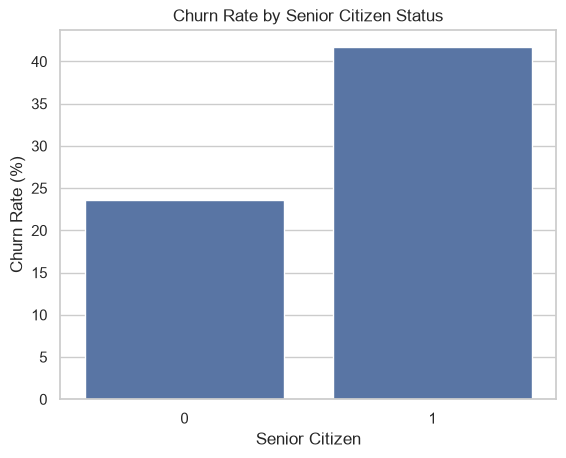

In [50]:
sns.barplot(
    x=senior_churn.index,
    y=senior_churn.values
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate (%)")

plt.show()
# 0 for no and 1 for yes

### Correlation Analysis

In [51]:
corr_df = df[
    [
        "SeniorCitizen",
        "tenure",
        "MonthlyCharges",
        "TotalCharges"
    ]
].copy()

corr_df["SeniorCitizen"] = corr_df["SeniorCitizen"].map({
    "No": 0,
    "Yes": 1
})

In [52]:
corr_df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [53]:
correlation = corr_df.corr()

correlation

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
SeniorCitizen,NaN,NaN,NaN,NaN,NaN
tenure,NaN,1.000000,0.247900,0.826178,-0.352229
MonthlyCharges,NaN,0.247900,1.000000,0.651174,0.193356
TotalCharges,NaN,0.826178,0.651174,1.000000,-0.198324
Churn,NaN,-0.352229,0.193356,-0.198324,1.000000


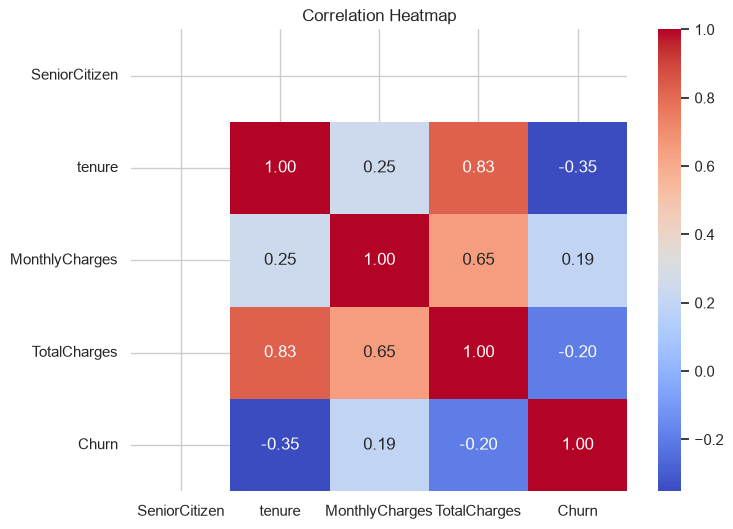

In [83]:
# Heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    os.path.join(reports_folder, "10_correlation_heatmap.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Monthly Charges vs Tenure Using Plotly

In [ ]:
fig = px.scatter(
    df,
    x="tenure",
    y="MonthlyCharges",
    color="Churn",
    hover_data=[
        "Contract",
        "InternetService",
        "PaymentMethod"
    ],
    title="Monthly Charges vs Tenure"
)

plt.savefig(
    os.path.join(reports_folder, "11_tenure_vs_monthly_charges.png"),
    dpi=300,
    bbox_inches="tight"
)
fig.show()
## Here we can interect with each customer

<Figure size 640x480 with 0 Axes>

## Revenue at Risk

In [57]:
churned_customers = df[df["Churn"] == "Yes"]

In [58]:
len(churned_customers)

1869

In [59]:
monthly_revenue_at_risk = (
    churned_customers["MonthlyCharges"].sum()
)

print(
    f"Monthly Revenue at Risk: ${monthly_revenue_at_risk:,.2f}"
)

Monthly Revenue at Risk: $139,130.85


In [60]:
annual_revenue_at_risk = monthly_revenue_at_risk * 12

print(
    f"Annualized Revenue at Risk: ${annual_revenue_at_risk:,.2f}"
)

Annualized Revenue at Risk: $1,669,570.20


In [61]:
# Final Dataset Check

print("Final Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Final Shape: (7043, 22)

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
TenureGroup         0
dtype: int64

Duplicate Rows:
0

Data Types:
customerID               str
gender                   str
SeniorCitizen          int64
Partner                  str
Dependents               str
tenure                 int64
PhoneService             str
MultipleLines            str
InternetService          str
OnlineSecurity           str
OnlineBackup             str
DeviceProtection         str
TechSupport              str
StreamingTV              str
StreamingMovies         



## 1. Overall Customer Churn

 The dataset contains **7,043 customers**, of which approximately **1,869 customers have churned** and **5,174 customers have been retained**.

 The overall churn rate is approximately **26.54%**.

 This means that roughly **1 out of every 4 customers** has left the company, making customer retention a major business priority.



## 2. Contract Type Has a Strong Relationship with Churn

 Customers with **Month-to-month contracts** have the highest churn rate.

 The churn rate for Month-to-month customers is approximately **42%**, compared with around **11% for One-year contracts** and **3% for Two-year contracts**.

### Business Impact:
 Customers on flexible contracts are significantly more likely to leave.

### Recommendation:
 The company should encourage month-to-month customers to move to longer contracts using:

- Contract upgrade discounts
- Loyalty benefits
- Free service upgrades
- Long-term customer rewards



## 3. New Customers Have the Highest Churn Risk

 Customers with shorter tenure show substantially higher churn rates.

 Customers in the **0–6 month** group have a churn rate of approximately **55%**, while customers with **49+ months** of tenure have a much lower churn rate.

### Business Impact:
 The first few months of the customer relationship are critical.

### Recommendation:
 Introduce:

- New-customer onboarding
- First 90-day engagement campaigns
- Welcome discounts
- Proactive customer support



## 4. Higher Monthly Charges Are Associated with Churn

 Churned customers have an average monthly charge of approximately **$74.44**, compared with approximately **$61.27 for retained customers**.

 This represents a difference of approximately **$13.17 per month**.

### Business Impact:
 Higher-paying customers represent a valuable but potentially higher-risk segment.

### Recommendation:
 Identify high-value customers with high monthly charges and provide personalized retention offers.



## 5. Fiber Optic Customers Show Higher Churn

 Fiber optic customers have a churn rate of approximately **41.9%**, compared with approximately **19% for DSL customers**.

### Business Impact:
 Fiber customers represent an important high-risk customer segment.

### Recommendation:
 Investigate:

- Pricing
- Internet performance
- Technical support
- Competitor pricing
- Customer satisfaction #

